In [17]:
import numpy as np
import pandas as pd

In [18]:
np.random.seed(42)
n_samples = 1000
age = np.random.randint(18, 70, n_samples)                  # realistic adult age range

income = np.random.normal(50000, 15000, n_samples)
income = np.clip(income, 10000, None)                        # no negative income

hours_studied = np.random.normal(5, 2, n_samples)
hours_studied = np.clip(hours_studied, 0, None)               # no negative hours

# ============================================
# True relationship (used to generate the Dependent Variable)
# ============================================
b0 = -6          # intercept
b1 = 0.02        # effect of age
b2 = 0.00004     # effect of income
b3 = 0.8         # effect of hours_studied

z = b0 + b1*age + b2*income + b3*hours_studied
prob = 1 / (1 + np.exp(-z))

# ============================================
# Dependent Variable (y) - sampled from probability, not deterministic
# ============================================
target = np.random.binomial(1, prob)

# ============================================
# Combine into final dataset
# ============================================
df = pd.DataFrame({
    'age': age,                       # Independent Variable
    'income': income,                 # Independent Variable
    'hours_studied': hours_studied,   # Independent Variable
    'target': target                  # Dependent Variable
})

print("Dataset shape:", df.shape)
print(df.head())
print("\nSummary stats:")
print(df.describe())
print("\nTarget class balance:")
print(df['target'].value_counts())


Dataset shape: (1000, 4)
   age        income  hours_studied  target
0   56  25903.305196       8.453928       1
1   69  53051.954538       4.200728       1
2   46  38654.738821       5.449369       0
3   32  28666.194356       6.865182       1
4   60  40301.406736       2.163269       1

Summary stats:
              age        income  hours_studied       target
count  1000.00000   1000.000000    1000.000000  1000.000000
mean     43.81900  50870.247574       5.045017     0.657000
std      14.99103  14804.290901       1.949951     0.474949
min      18.00000  10000.000000       0.000000     0.000000
25%      31.00000  40822.467127       3.717034     0.000000
50%      44.00000  50807.530986       5.007628     1.000000
75%      56.00000  60282.053126       6.368513     1.000000
max      69.00000  89485.730973      11.386215     1.000000

Target class balance:
target
1    657
0    343
Name: count, dtype: int64


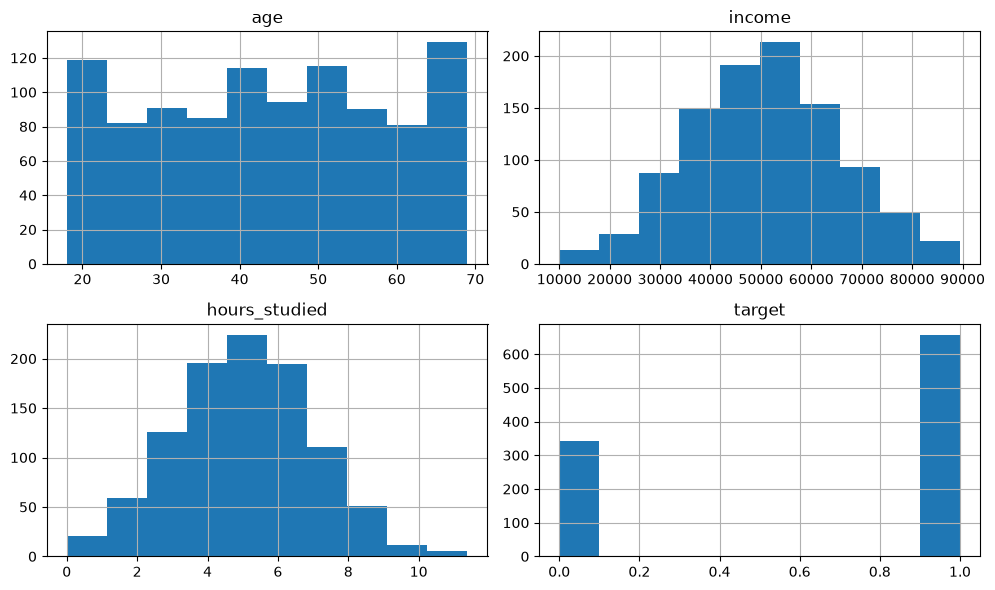

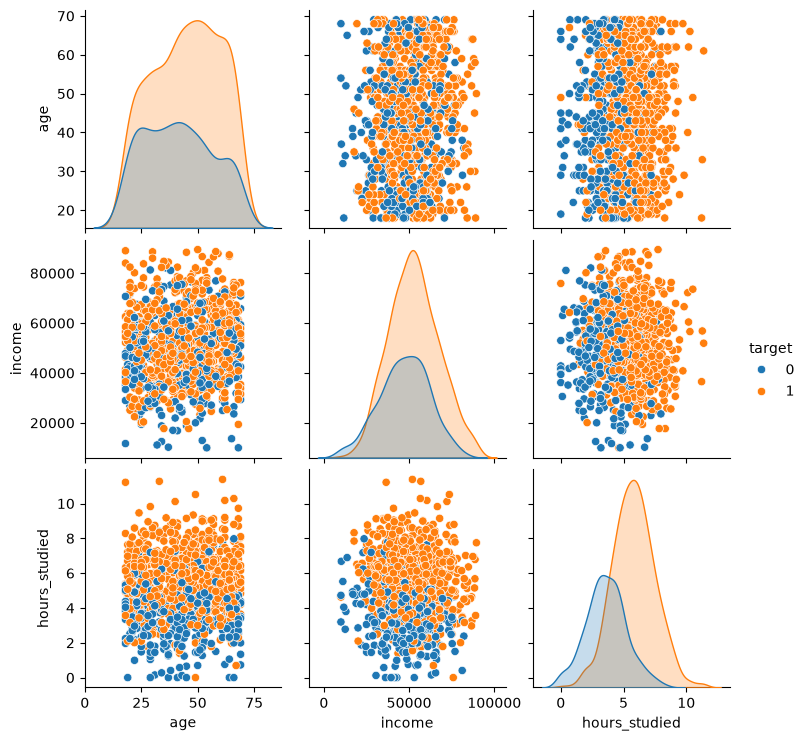

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distributions of each variable
df.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

# Relationship between features and target
sns.pairplot(df, hue='target')
plt.show()

Accuracy: 0.825
Coefficients: [[1.62939526e-02 4.62857159e-05 9.22531321e-01]]
Intercept: [-6.68709688]


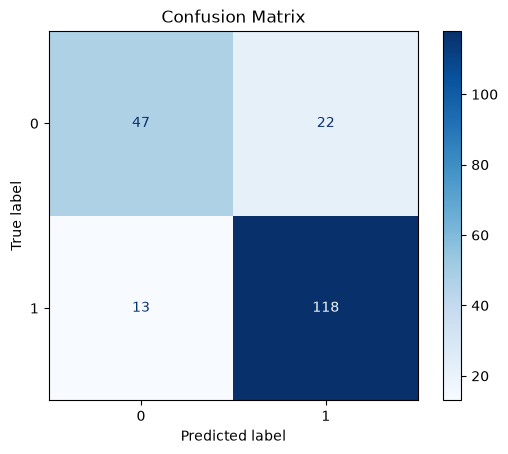

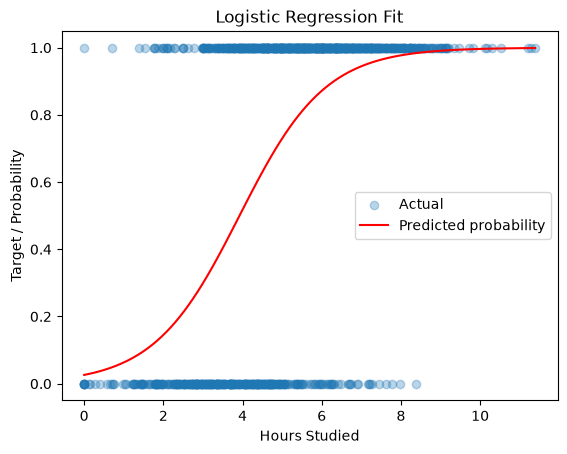

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Split independent (X) and dependent (y) variables
X = df[['age', 'income', 'hours_studied']]
y = df['target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit logistic regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# ---- Plot 1: Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# ---- Plot 2: Sigmoid curve (probability vs one feature) ----
x_vals = np.linspace(df['hours_studied'].min(), df['hours_studied'].max(), 100)
z = model.intercept_[0] + model.coef_[0][2]*x_vals + \
    model.coef_[0][0]*df['age'].mean() + model.coef_[0][1]*df['income'].mean()
y_curve = 1 / (1 + np.exp(-z))

plt.scatter(df['hours_studied'], df['target'], alpha=0.3, label='Actual')
plt.plot(x_vals, y_curve, color='red', label='Predicted probability')
plt.xlabel('Hours Studied')
plt.ylabel('Target / Probability')
plt.legend()
plt.title("Logistic Regression Fit")
plt.show()